# GME on a 2D Cluster State — Step by Step

This notebook walks through the full procedure for proving Genuine Multipartite Entanglement (GME) on IQM hardware, end to end.

**Goal**: prove that all n qubits in a 2D cluster state are genuinely entangled together — not just pairwise.

We use a 2×3 grid (6 qubits) as the smallest meaningful demonstration. The exact same code scales to 6×9 = 54 qubits with no change.

## 1. The grid

We pick a 2×3 rectangle of qubits on the IQM Emerald square lattice:

```
   qubit 0 ── qubit 1 ── qubit 2     (top row)
      │         │         │
   qubit 3 ── qubit 4 ── qubit 5     (bottom row)
```

Each `──` is an edge in the graph G. Our cluster state |C_G⟩ will have exactly one CZ gate per edge.

**Why a grid?** IQM Emerald is physically a square lattice. Picking a rectangular sub-grid means every CZ gate maps directly to a native 2-qubit operation on hardware — no SWAPs, no transpilation overhead.

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import get_backend, is_simulator
from src.circuits.cluster_2d import build_cluster_2d_no_measure, checkerboard_coloring
from src.witnesses.gme_cluster import build_gme_circuits, compute_gme_witness, gme_significance

ROWS, COLS = 2, 3
N = ROWS * COLS
SHOTS = 4000

backend = get_backend(device='emerald')   # uses $IQM_TOKEN if set, else Aer simulator
print(f'Backend: {backend}')
print(f'Hardware: {not is_simulator(backend)}')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x000002214CCD4650>
Hardware: True


## 2. Build the cluster state

The cluster state on graph G is defined by:

$$|C_G\rangle = \prod_{(i,j) \in E(G)} \mathrm{CZ}_{ij} \cdot H^{\otimes n} |0\rangle^{\otimes n}$$

Read left to right, this is a 3-layer recipe:

**Layer 1** — apply H to every qubit. Each qubit goes from $|0\rangle$ to $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$. State is now a product of 6 independent superpositions — **no entanglement yet**.

**Layer 2** — apply CZ to every horizontal edge: (0,1), (1,2), (3,4), (4,5). Four gates, all parallel (they share no qubits with each other).

**Layer 3** — apply CZ to every vertical edge: (0,3), (1,4), (2,5). Three gates, all parallel.

**That's it.** Total depth: 3. This depth does not grow with qubit count — a 54-qubit cluster state has exactly the same depth.

Qubits: 6
Gate counts: {'cz': 7, 'h': 6, 'barrier': 2}
Depth (with barriers): 4


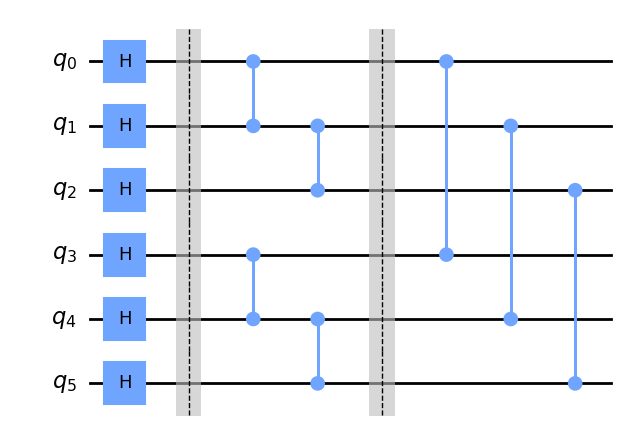

In [2]:
state_circuit = build_cluster_2d_no_measure(ROWS, COLS)
print(f'Qubits: {state_circuit.num_qubits}')
print(f'Gate counts: {dict(state_circuit.count_ops())}')
print(f'Depth (with barriers): {state_circuit.depth()}')

state_circuit.draw('mpl', style='clifford')

## 3. The GME witness — what we will measure

Cluster states are **stabilizer states**: they are uniquely defined as the +1 eigenstate of n operators called *stabilizers*.

For each qubit i:
$$g_i = X_i \otimes \bigotimes_{j \in N(i)} Z_j$$

where $N(i)$ are the graph neighbors of qubit i. For a perfect cluster state, every $\langle g_i \rangle = +1$.

**Witness**:
$$W = \sum_{i=1}^n \langle g_i \rangle$$

**Bounds** (Tóth & Gühne 2005):
- Ideal cluster state: $W = n$
- Any biseparable state: $W \leq n - 1$

So if our measurement gives $W > n - 1$, we have **proven** the state is genuinely multipartitely entangled — there is no way to split the qubits into two independent groups.

For our 2×3 grid: ideal $W = 6$, bound $W = 5$. We need W > 5 to certify GME.

## 4. Why only 2 measurement settings — the checkerboard trick

Each stabilizer $g_i$ requires measuring qubit i in the X basis and its neighbors in the Z basis. Naively you'd think we need n different circuits — one per qubit — but there's a beautiful shortcut.

The square lattice is **2-colorable** like a chessboard:

```
   B  W  B            qubits 0,2,4 = black
   W  B  W            qubits 1,3,5 = white
```

Every edge connects a black qubit to a white one. So:

**Setting A**: measure all **black** qubits in X basis, all **white** qubits in Z basis.  
→ This gives us $\langle g_i \rangle$ for every black qubit (qubit i in X, its white neighbors in Z) — all in **one circuit**.

**Setting B**: measure all **white** qubits in X basis, all **black** qubits in Z basis.  
→ This gives us $\langle g_i \rangle$ for every white qubit.

Two circuits, the entire witness. This number stays at 2 forever — for 54 qubits, for 1000 qubits, doesn't matter.

In [3]:
# Visualize the coloring
coloring = checkerboard_coloring(ROWS, COLS)
print('Checkerboard coloring (B=black, W=white):')
for r in range(ROWS):
    print('  ' + ' '.join('B' if coloring[r*COLS+c]==0 else 'W' for c in range(COLS)))
print()
print(f'Black qubits (X-measured in setting A): {[i for i, c in enumerate(coloring) if c==0]}')
print(f'White qubits (X-measured in setting B): {[i for i, c in enumerate(coloring) if c==1]}')

Checkerboard coloring (B=black, W=white):
  B W B
  W B W

Black qubits (X-measured in setting A): [0, 2, 4]
White qubits (X-measured in setting B): [1, 3, 5]


## 5. Build the two measurement circuits

X-basis measurement: apply H before measuring in the computational basis.  
Z-basis measurement: just measure (no rotation needed).

Setting A: depth=6, gates={'h': 9, 'cz': 7, 'measure': 6, 'barrier': 3}
Setting B: depth=6, gates={'h': 9, 'cz': 7, 'measure': 6, 'barrier': 3}


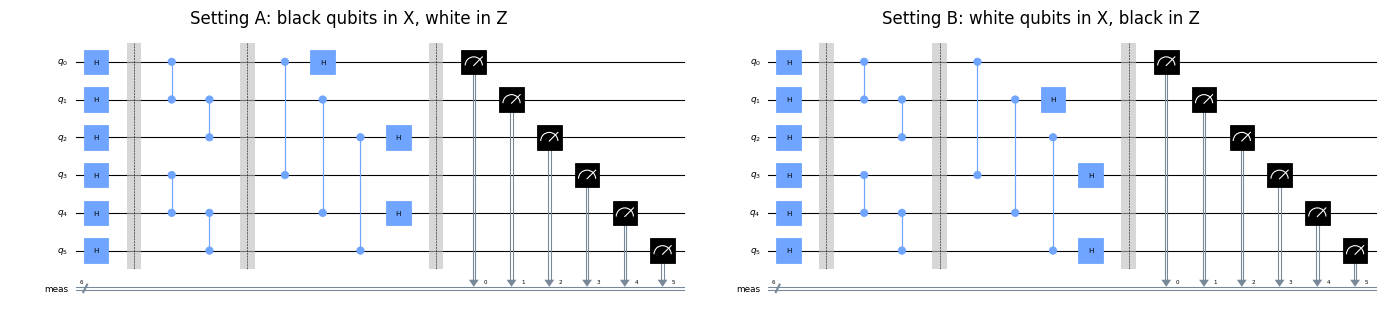

In [4]:
circ_a, circ_b = build_gme_circuits(state_circuit, ROWS, COLS)

print(f'Setting A: depth={circ_a.depth()}, gates={dict(circ_a.count_ops())}')
print(f'Setting B: depth={circ_b.depth()}, gates={dict(circ_b.count_ops())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
circ_a.draw('mpl', ax=axes[0], style='clifford')
axes[0].set_title('Setting A: black qubits in X, white in Z')
circ_b.draw('mpl', ax=axes[1], style='clifford')
axes[1].set_title('Setting B: white qubits in X, black in Z')
plt.tight_layout()
plt.show()

## 6. Run on hardware

Two circuits, batched into a single IQM job. 4000 shots each — well below the 20K/job limit.

We let Qiskit transpile to the device topology with `optimization_level=3` (best). On IQM Emerald, CZ and H are both native, so transpilation is essentially free.

In [5]:
transpiled = transpile([circ_a, circ_b], backend=backend, optimization_level=3)
print(f'After transpilation: depth A={transpiled[0].depth()}, depth B={transpiled[1].depth()}')

job = backend.run(transpiled, shots=SHOTS)
try:
    print(f'Job ID: {job.job_id()}')
except Exception:
    pass
result = job.result()
counts = result.get_counts()
if isinstance(counts, dict):
    counts_a = counts_b = counts
else:
    counts_a, counts_b = counts[0], counts[1]
print(f'Setting A: {len(counts_a)} distinct outcomes')
print(f'Setting B: {len(counts_b)} distinct outcomes')

After transpilation: depth A=6, depth B=6


Job ID: 019e0c9d-9930-7281-b7d2-feeee1e023d7


Setting A: 54 distinct outcomes
Setting B: 51 distinct outcomes


## 7. Compute the witness

For each qubit i, the stabilizer expectation is computed from the right circuit:
- Black qubit: read from setting A's bitstrings
- White qubit: read from setting B's bitstrings

For each shot, the stabilizer eigenvalue is
$$g_i = (-1)^{b_i + \sum_{j \in N(i)} b_j}$$
where $b_k$ is the measured bit (0 or 1) for qubit k. Average over shots gives $\langle g_i \rangle$.

In [6]:
res = compute_gme_witness(counts_a, counts_b, ROWS, COLS)
sigma = gme_significance(res['W'], N, SHOTS)

print('=' * 50)
print(f'  W (measured)        = {res["W"]:.4f}')
print(f'  W ideal             = {res["W_ideal"]:.0f}')
print(f'  Biseparable bound   = {res["biseparable_bound"]}  (need W > this)')
print(f'  Violation           = {res["violation"]:.4f}')
print(f'  Statistical sigma   = {sigma:.2f}')
print(f'  W / W_ideal         = {res["W"]/res["W_ideal"]*100:.1f}%')
print(f'  GME CERTIFIED?      = {"YES" if res["is_gme"] else "NO"}')
print('=' * 50)

  W (measured)        = 5.4920
  W ideal             = 6
  Biseparable bound   = 5  (need W > this)
  Violation           = 0.4920
  Statistical sigma   = 12.70
  W / W_ideal         = 91.5%
  GME CERTIFIED?      = YES


## 8. Per-qubit breakdown — heatmap

Plot each $\langle g_i \rangle$ on the grid. For an ideal cluster state, every cell is +1 (deep green). Hardware noise pulls these values down — if any cell is significantly below the others, that qubit had problems.

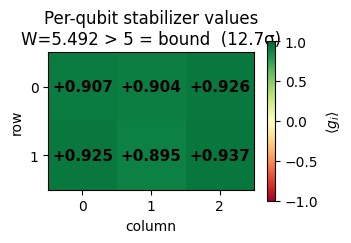

In [7]:
stab = res['stabilizer_values']
grid = np.array([[stab[r*COLS+c] for c in range(COLS)] for r in range(ROWS)])

fig, ax = plt.subplots(figsize=(COLS*1.2, ROWS*1.2))
im = ax.imshow(grid, vmin=-1, vmax=1, cmap='RdYlGn')
for r in range(ROWS):
    for c in range(COLS):
        ax.text(c, r, f'{grid[r,c]:+.3f}', ha='center', va='center', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label=r'$\langle g_i \rangle$')
ax.set_title(f'Per-qubit stabilizer values\n'
             f'W={res["W"]:.3f} > {res["biseparable_bound"]} = bound  ({sigma:.1f}σ)')
ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
ax.set_xlabel('column'); ax.set_ylabel('row')
plt.tight_layout()
plt.show()

## 9. What the result means

If we measured **W > 5** with high σ, then:

1. **The state is GME** — there is no way to split the 6 qubits into two independent groups. Every qubit is genuinely entangled with every other.

2. **Local hidden variable theories are ruled out** — like CHSH, the violation is impossible to explain with classical correlations.

3. **Hardware fidelity is high** — W/n = $\langle g_i \rangle_{\text{avg}}$ is a direct fidelity proxy. Values > 0.9 mean the gates are working close to spec.

## What changes for larger grids

**Nothing in the procedure**. The same `build_cluster_2d_no_measure(rows, cols)` and `build_gme_circuits` and `compute_gme_witness` work for any size.

What scales:
- Ideal value W: grows linearly with n (as n)
- Bound: also grows linearly (as n−1)
- Significance σ: `(W − (n−1)) · √(shots/n)` — depends on whether per-qubit fidelities stay high

**Where it eventually fails**: when accumulated gate errors push average $\langle g_i \rangle$ below $1 - 1/n$ (i.e. W < n−1), GME can no longer be certified. Our scaling notebook (04) maps out exactly where this happens on Emerald.